!['svg'](fig/IV.svg)

发生变化的量：

1. 同电压处电流值：改变灯丝电压，同一电压下波形有纵向的拉伸或压缩（固定I=0，所以不是平移而是向上拉伸压缩）；本实验中减小了灯丝电压，电流减小。这是因为灯丝电压与发射电子量正相关，进而与电流正相关
2. 峰谷处电流值：改变第一栅极电压，大部分区域电流值接近，只有在极大极小值点附近分离；本实验中减小了第一栅极电压，曲线极大极小值点上移。总体而言，第一栅极电压对曲线影响较小，因为第一栅极主要作用是消除空间电荷效应，帮助电子加速飞向第二栅极。在正常范围内变化时，只要它能有效加速电子，对最终测量曲线的影响就不大。至于为什么有提高极值点的作用，经查询得知存在一个最佳第一栅极电流值，因为不仅要考虑消除空间电荷效应，还要考虑电子束过加速碰撞概率下降与聚焦变差的问题。当标准值高于这个最佳值时，减小电压反而会让电子束“质量”变好，从而提高收集效率。
3. 同一电流对应电压值平移：改变拒斥电压，除曲线纵向变化外，还出现了横向的平移；本实验提高了拒斥电压，电流值减小，曲线右移1.5~2V，接近增加值（2V）。增大的电压值相当于补偿了拒斥电压的增加值，同时拒斥电压增大，到达阳极的电子数减少，电流减小。

基本不变的量

1. 第一激发电位：4次实验测量值都接近理论值。由氩原子核电荷数决定，不受测量时的采用的参数影响

![标准](fig/标准IV.svg)

In [174]:
df=标准;pd.DataFrame({'极大值I/μA':极大值(df),'极大值点U/V':极大值点(df)})

,极大值I/μA,极大值点U/V
0,0.898,34.0
1,2.494,44.0
2,4.556,55.0
3,6.857,66.5
4,9.262,78.5


In [175]:
pd.DataFrame({'极小值I/μA':极小值(df),'极小值点U/V':极小值点(df)})

,极小值I/μA,极小值点U/V
0,0.807,36.0
1,1.507,48.0
2,2.234,59.5
3,3.466,71.5


![](fig/灯丝IV.svg)


In [176]:
df=灯丝;pd.DataFrame({'极大值I/μA':极大值(df),'极大值点U/V':极大值点(df)})

,极大值I/μA,极大值点U/V
0,0.507,33.0
1,1.388,44.0
2,2.587,55.0
3,3.958,66.5
4,5.364,78.5


In [177]:
pd.DataFrame({'极小值I/μA':极小值(df),'极小值点U/V':极小值点(df)})

,极小值I/μA,极小值点U/V
0,0.166,24.5
1,0.401,37.0
2,0.815,48.5
3,1.276,59.5
4,1.932,71.5


![](fig/栅极IV.svg)

In [178]:
df=栅极;pd.DataFrame({'极大值I/μA':极大值(df),'极大值点U/V':极大值点(df)})

,极大值I/μA,极大值点U/V
0,0.996,33.5
1,2.736,44.0
2,5.009,55.0
3,7.614,66.5
4,10.360,78.0


In [179]:
pd.DataFrame({'极小值I/μA':极小值(df),'极小值点U/V':极小值点(df)})

,极小值I/μA,极小值点U/V
0,0.833,37.0
1,1.614,48.0
2,2.499,59.5
3,3.836,71.5


![](fig/拒斥IV.svg)

In [180]:
df=拒斥;pd.DataFrame({'极大值I/μA':极大值(df),'极大值点U/V':极大值点(df)})

,极大值I/μA,极大值点U/V
0,0.607,33.5
1,1.607,44.5
2,3.567,56.0
3,6.052,67.5
4,8.522,79.5


In [181]:
pd.DataFrame({'极小值I/μA':极小值(df),'极小值点U/V':极小值点(df)})

,极小值I/μA,极小值点U/V
0,0.201,26.0
1,0.401,38.0
2,0.675,49.5
3,1.128,61.0
4,1.990,73.0


附录一：数据

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# 设置宋体（Windows 系统常用 'SimSun'，也可用 'SimHei' 等）
plt.rcParams['font.sans-serif'] = ['SimSun']  # 或 'SimHei', 'Microsoft YaHei'
# 解决负号显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False

In [51]:
标准=pd.read_excel('数据.xlsx', sheet_name="标准")
灯丝=pd.read_excel('数据.xlsx', sheet_name="灯丝")
栅极=pd.read_excel('数据.xlsx', sheet_name="栅极")
栅极.interpolate(method='linear', axis=0,inplace=True)
拒斥=pd.read_excel('数据.xlsx', sheet_name="拒斥")

In [ ]:
# pd.set_option('display.max_rows', None)
pd.DataFrame({'电压':标准['V'],'标准电压':标准['I'],'灯丝电压-0.1V':灯丝['I'],'第一栅极电压-0.2V':栅极['I'],'拒斥电压+2V':拒斥['I']})

附录二：计算画图代码

In [6]:
def 极小值点(df):
    # 提取数据（按位置取前两列，避免列名不匹配）
    U = df['V']
    I = df['I']
    
    # 确保数据长度至少为 3 才能判断局部极小值
    if len(U) < 3:
        return []
    
    # 寻找局部极小值索引（忽略首尾）
    min_idx = [i for i in range(2, len(I)-2) if  I[i] < I[i-1] and I[i] < I[i+1] and I[i] < I[i-2] and I[i] < I[i+2]]
    
    # 筛选 U 非零的极小值，提取对应 I
    result = [U[i] for i in min_idx if U[i]>20]
    
    return result

In [7]:
def 极大值点(df):
    # 提取数据（按位置取前两列，避免列名不匹配）
    U = df['V']
    I = df['I']
    
    # 确保数据长度至少为 3 才能判断局部极小值
    if len(U) < 3:
        return []
    
    # 寻找局部极小值索引（忽略首尾）
    max_idx = [i for i in range(2, len(I)-2) if  I[i] > I[i-1] and I[i] > I[i+1] and I[i] > I[i-2] and I[i] > I[i+2]]
    
    # 筛选 U 非零的极小值，提取对应 I
    result = [U[i] for i in max_idx if U[i]>20]
    
    return result

In [8]:
def 极小值(df):
    """
    从包含两列（U, I）的 DataFrame 中，提取所有非零局部极小值 U 对应的 I。

    参数:
        df (pd.DataFrame): 至少包含两列数据的 DataFrame，第一列为 U，第二列为 I。

    返回:
        list: 满足条件的 I 值列表。
    """
    # 提取数据（按位置取前两列，避免列名不匹配）
    U = df['V']
    I = df['I']
    
    # 确保数据长度至少为 3 才能判断局部极小值
    if len(U) < 3:
        return []
    
    # 寻找局部极小值索引（忽略首尾）
    min_idx = [i for i in range(2, len(I)-2) if  I[i] < I[i-1] and I[i] < I[i+1] and I[i] < I[i-2] and I[i] < I[i+2]]
    
    # 筛选 U 非零的极小值，提取对应 I
    result = [I[i] for i in min_idx if U[i]>20]
    
    return result

In [9]:
def 极大值(df):
    """
    从包含两列（U, I）的 DataFrame 中，提取所有非零局部极小值 U 对应的 I。

    参数:
        df (pd.DataFrame): 至少包含两列数据的 DataFrame，第一列为 U，第二列为 I。

    返回:
        list: 满足条件的 I 值列表。
    """
    # 提取数据（按位置取前两列，避免列名不匹配）
    U = df['V']
    I = df['I']
    
    # 确保数据长度至少为 3 才能判断局部极小值
    if len(U) < 3:
        return []
    
    # 寻找局部极小值索引（忽略首尾）
    max_idx = [i for i in range(2, len(I)-2) if  I[i] > I[i-1] and I[i] > I[i+1] and I[i] > I[i-2] and I[i] > I[i+2]]
    
    # 筛选 U 非零的极小值，提取对应 I
    result = [I[i] for i in max_idx if U[i]>20]
    
    return result

In [10]:
def 回归(y, x=None, start=0, force_zero=False):
    """
    一元线性回归 y = a + b*x，可选强制 a=0。

    参数:
        x (array-like): 自变量
        y (array-like): 因变量
        force_zero (bool): 是否强制截距 a 为 0（过原点），默认 False

    返回:
        tuple: (a, b) 截距和斜率
    """
    y = np.asarray(y)
    if x == None:
        x=np.arange(len(y))
    x+=start
    
    if force_zero:
        # 过原点模型 y = b*x
        # 最小二乘解：b = Σ(x*y) / Σ(x^2)
        b = np.sum(x * y) / np.sum(x * x)
        a = 0.0
    else:
        # 标准线性回归，使用 polyfit (一次多项式)
        # polyfit 返回 [斜率, 截距] 或 [b, a]
        coef = np.polyfit(x, y, 1)
        b, a = coef[0], coef[1]
    
    return a, b

In [11]:
def 画图(y, x):
    y = np.asarray(y)
    if x == None:
        x=np.arange(len(y))
    plt.scatter(x,y)

In [12]:
def 第一电离电位(name):
    df=pd.read_excel('数据.xlsx', sheet_name=name)
    # m=极小值点(df)
    # print(m)
    b=回归(极小值点(df))[1]
    return b

In [13]:
第一电离电位("标准")

np.float64(11.799999999999999)

In [14]:
第一电离电位("灯丝")

np.float64(11.649999999999997)

In [15]:
第一电离电位("栅极")

np.float64(11.500000000000002)

In [16]:
第一电离电位("拒斥")

np.float64(11.700000000000001)

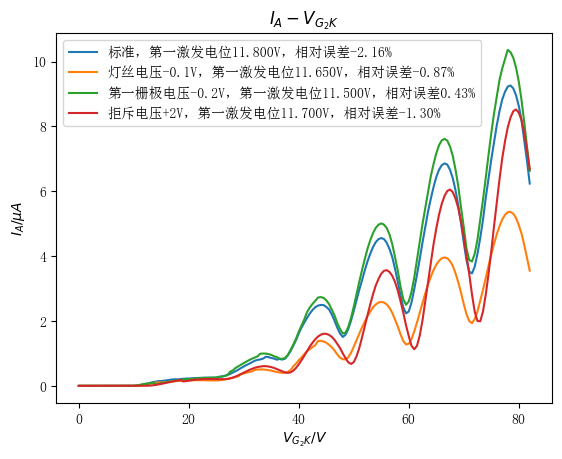

In [17]:
# plt.scatter(标准['V'],标准['I'],marker='x')
# plt.scatter(标准['V'],灯丝['I'],marker='x')
# plt.scatter(标准['V'],栅极['I'],marker='x')
# plt.scatter(标准['V'],拒斥['I'],marker='x')
plt.title(r'$I_A-V_{G_2K}$')
plt.plot(标准['V'],标准['I'],label=f"标准，第一激发电位{第一电离电位("标准"):.3f}V，相对误差{(11.55-第一电离电位("标准"))/11.55:.2%}")
plt.plot(标准['V'],灯丝['I'],label=f"灯丝电压-0.1V，第一激发电位{第一电离电位("灯丝"):.3f}V，相对误差{(11.55-第一电离电位("灯丝"))/11.55:.2%}")
plt.plot(标准['V'],栅极['I'],label=f"第一栅极电压-0.2V，第一激发电位{第一电离电位("栅极"):.3f}V，相对误差{(11.55-第一电离电位("栅极"))/11.55:.2%}")
plt.plot(标准['V'],拒斥['I'],label=f"拒斥电压+2V，第一激发电位{第一电离电位("拒斥"):.3f}V，相对误差{(11.55-第一电离电位("拒斥"))/11.55:.2%}")
plt.ylabel(r'$I_A/\mu A$')
plt.xlabel(r'$V_{G_2K}/V$')
plt.legend()
plt.savefig('IV.svg', format='svg', bbox_inches='tight')
plt.show()

In [18]:
np.asarray(极小值点(拒斥))[1:]-np.asarray(极小值点(标准))

array([2. , 1.5, 1.5, 1.5])

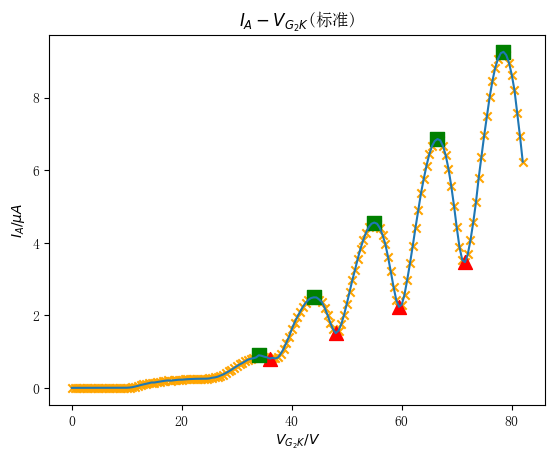

In [19]:
df=标准
plt.scatter(df['V'],df['I'],marker='x',c='orange')
plt.scatter(极小值点(df),极小值(df),marker='^',c='red', s=100)
plt.scatter(极大值点(df),极大值(df),marker='s',c='green', s=100)
plt.title(r'$I_A-V_{G_2K}$(标准)')
plt.plot(df['V'],df['I'])
plt.ylabel(r'$I_A/\mu A$')
plt.xlabel(r'$V_{G_2K}/V$')
plt.savefig('标准IV.svg', format='svg', bbox_inches='tight')
plt.show()

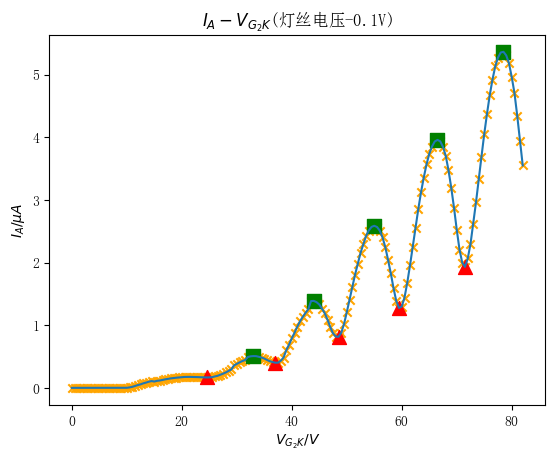

In [20]:
df=灯丝
plt.scatter(df['V'],df['I'],marker='x',c='orange')
plt.scatter(极小值点(df),极小值(df),marker='^',c='red', s=100)
plt.scatter(极大值点(df),极大值(df),marker='s',c='green', s=100)
plt.title(r'$I_A-V_{G_2K}$(灯丝电压-0.1V)')
plt.plot(df['V'],df['I'])
plt.ylabel(r'$I_A/\mu A$')
plt.xlabel(r'$V_{G_2K}/V$')
plt.savefig('灯丝IV.svg', format='svg', bbox_inches='tight')
plt.show()

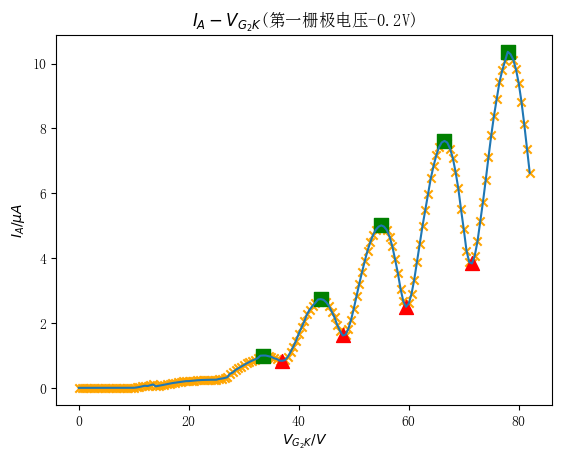

In [21]:
df=栅极
plt.scatter(df['V'],df['I'],marker='x',c='orange')
plt.scatter(极小值点(df),极小值(df),marker='^',c='red', s=100)
plt.scatter(极大值点(df),极大值(df),marker='s',c='green', s=100)
plt.title(r'$I_A-V_{G_2K}$(第一栅极电压-0.2V)')
plt.plot(df['V'],df['I'])
plt.ylabel(r'$I_A/\mu A$')
plt.xlabel(r'$V_{G_2K}/V$')
plt.savefig('栅极IV.svg', format='svg', bbox_inches='tight')
plt.show()

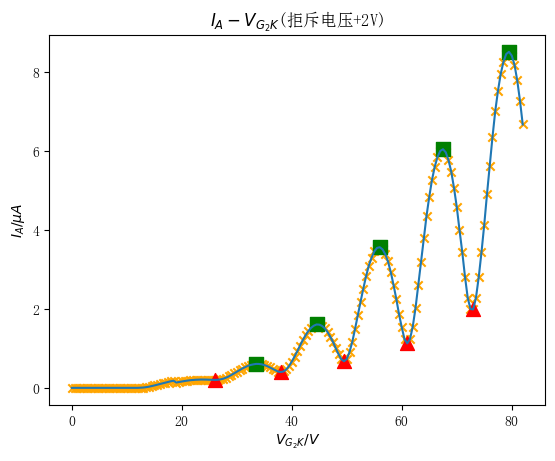

In [23]:
df=拒斥
plt.scatter(df['V'],df['I'],marker='x',c='orange')
plt.scatter(极小值点(df),极小值(df),marker='^',c='red', s=100)
plt.scatter(极大值点(df),极大值(df),marker='s',c='green', s=100)
plt.title(r'$I_A-V_{G_2K}$(拒斥电压+2V)')
plt.plot(df['V'],df['I'])
plt.ylabel(r'$I_A/\mu A$')
plt.xlabel(r'$V_{G_2K}/V$')
plt.savefig('拒斥IV.svg', format='svg', bbox_inches='tight')
plt.show()

In [59]:
第二主频=np.zeros(4)
第三主频=np.zeros(4)
第四主频=np.zeros(4)

按幅值排序的前几个频率:
第1大: 频率 = 0.0121 /V, 周期 = 82.50 V, 幅值 = 87.55
第2大: 频率 = 0.0848 /V, 周期 = 11.79 V, 幅值 = 64.68
第3大: 频率 = 0.0970 /V, 周期 = 10.31 V, 幅值 = 44.27
第4大: 频率 = 0.0727 /V, 周期 = 13.75 V, 幅值 = 41.87


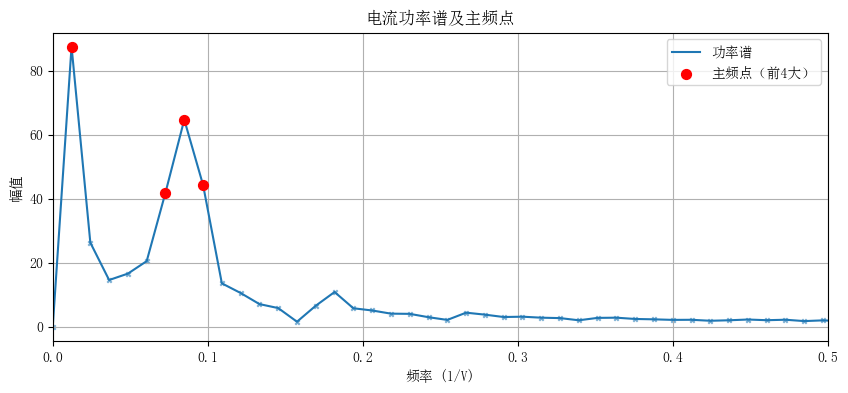

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import detrend
from scipy.fft import fft, fftfreq

df = 标准
# 假设 df 是您的 DataFrame
I = df['I'].values
I = detrend(I, type='linear')
dt = 0.5
N = len(I)
fft_vals = fft(I)                      # 未去趋势
freqs = fftfreq(N, d=dt)

# 只取正频率部分
amp = np.abs(fft_vals[:N//2])
freq_pos = freqs[:N//2]

# 排除直流分量（频率为0）和极低频（可选）
min_freq = -1
mask = freq_pos > min_freq
freq_masked = freq_pos[mask]
amp_masked = amp[mask]

# 按幅值降序排序，获取索引
sorted_idx = np.argsort(amp_masked)[::-1]   # 从大到小排序

# 确保有足够的频率点
if len(sorted_idx) >= 4:
    # 取第2、3、4大主频（索引1、2、3）
    second_freq = freq_masked[sorted_idx[1]]
    third_freq = freq_masked[sorted_idx[2]]
    fourth_freq = freq_masked[sorted_idx[3]]
    
    # 记录到数组中（假设已定义）
    第二主频[0] = second_freq
    第三主频[0] = third_freq
    第四主频[0] = fourth_freq
    
    # 打印结果
    print("按幅值排序的前几个频率:")
    for i in range(min(4, len(sorted_idx))):
        print(f"第{i+1}大: 频率 = {freq_masked[sorted_idx[i]]:.4f} /V, "
              f"周期 = {1/freq_masked[sorted_idx[i]]:.2f} V, "
              f"幅值 = {amp_masked[sorted_idx[i]]:.2f}")
else:
    print("频率点不足4个，无法获取第二、三、四主频。")

# 绘制功率谱并标记所有峰值（可选，保留原始绘图逻辑，但改为用排序后的前几个作为标记）
plt.figure(figsize=(10, 4))
plt.plot(freq_pos, amp, label='功率谱')
plt.scatter(freq_pos, amp, marker='x', s=10, alpha=0.6)
# 标记前四个最大幅值的点（可选）
if len(sorted_idx) >= 4:
    top_freqs = freq_masked[sorted_idx[:4]]
    top_amps = amp_masked[sorted_idx[:4]]
    plt.scatter(top_freqs, top_amps, color='red', s=50, zorder=5, label='主频点（前4大）')
plt.xlim(0, 0.5)
plt.xlabel('频率 (1/V)')
plt.ylabel('幅值')
plt.title('电流功率谱及主频点')
plt.legend()
plt.grid()
plt.show()

按幅值排序的前几个频率:
第1大: 频率 = 0.0121 /V, 周期 = 82.50 V, 幅值 = 53.63
第2大: 频率 = 0.0848 /V, 周期 = 11.79 V, 幅值 = 38.31
第3大: 频率 = 0.0970 /V, 周期 = 10.31 V, 幅值 = 26.89
第4大: 频率 = 0.0727 /V, 周期 = 13.75 V, 幅值 = 23.50


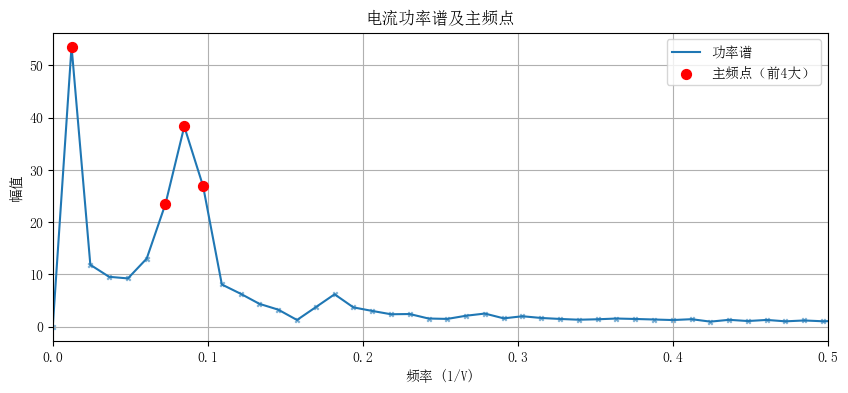

In [66]:
df=灯丝
# 假设 df 是您的 DataFrame
I = df['I'].values
I = detrend(I, type='linear')
dt = 0.5
N = len(I)
fft_vals = fft(I)                      # 未去趋势
freqs = fftfreq(N, d=dt)

# 只取正频率部分
amp = np.abs(fft_vals[:N//2])
freq_pos = freqs[:N//2]

# 排除直流分量（频率为0）和极低频（可选）
min_freq = -1
mask = freq_pos > min_freq
freq_masked = freq_pos[mask]
amp_masked = amp[mask]

# 按幅值降序排序，获取索引
sorted_idx = np.argsort(amp_masked)[::-1]   # 从大到小排序

# 确保有足够的频率点
if len(sorted_idx) >= 4:
    # 取第2、3、4大主频（索引1、2、3）
    second_freq = freq_masked[sorted_idx[1]]
    third_freq = freq_masked[sorted_idx[2]]
    fourth_freq = freq_masked[sorted_idx[3]]
    
    # 记录到数组中（假设已定义）
    第二主频[1] = second_freq
    第三主频[1] = third_freq
    第四主频[1] = fourth_freq
    
    # 打印结果
    print("按幅值排序的前几个频率:")
    for i in range(min(4, len(sorted_idx))):
        print(f"第{i+1}大: 频率 = {freq_masked[sorted_idx[i]]:.4f} /V, "
              f"周期 = {1/freq_masked[sorted_idx[i]]:.2f} V, "
              f"幅值 = {amp_masked[sorted_idx[i]]:.2f}")
else:
    print("频率点不足4个，无法获取第二、三、四主频。")

# 绘制功率谱并标记所有峰值（可选，保留原始绘图逻辑，但改为用排序后的前几个作为标记）
plt.figure(figsize=(10, 4))
plt.plot(freq_pos, amp, label='功率谱')
plt.scatter(freq_pos, amp, marker='x', s=10, alpha=0.6)
# 标记前四个最大幅值的点（可选）
if len(sorted_idx) >= 4:
    top_freqs = freq_masked[sorted_idx[:4]]
    top_amps = amp_masked[sorted_idx[:4]]
    plt.scatter(top_freqs, top_amps, color='red', s=50, zorder=5, label='主频点（前4大）')
plt.xlim(0, 0.5)
plt.xlabel('频率 (1/V)')
plt.ylabel('幅值')
plt.title('电流功率谱及主频点')
plt.legend()
plt.grid()
plt.show()

按幅值排序的前几个频率:
第1大: 频率 = 0.0121 /V, 周期 = 82.50 V, 幅值 = 97.92
第2大: 频率 = 0.0848 /V, 周期 = 11.79 V, 幅值 = 72.75
第3大: 频率 = 0.0970 /V, 周期 = 10.31 V, 幅值 = 50.69
第4大: 频率 = 0.0727 /V, 周期 = 13.75 V, 幅值 = 44.41


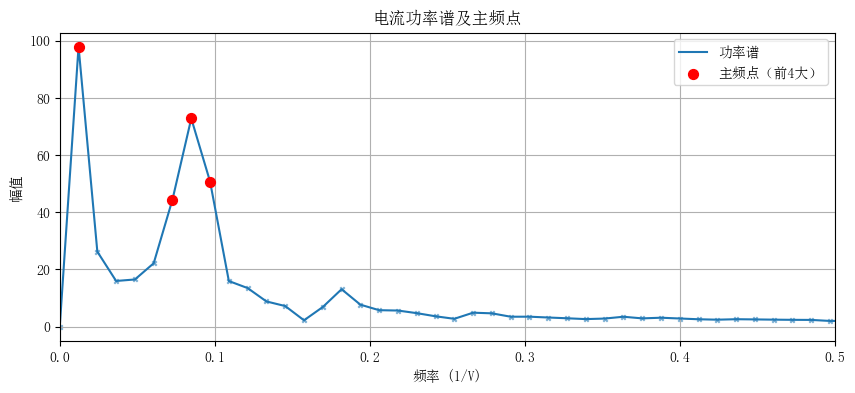

In [67]:
df=栅极
# 假设 df 是您的 DataFrame
I = df['I'].values
I = detrend(I, type='linear')
dt = 0.5
N = len(I)
fft_vals = fft(I)                      # 未去趋势
freqs = fftfreq(N, d=dt)

# 只取正频率部分
amp = np.abs(fft_vals[:N//2])
freq_pos = freqs[:N//2]

# 排除直流分量（频率为0）和极低频（可选）
min_freq = -1
mask = freq_pos > min_freq
freq_masked = freq_pos[mask]
amp_masked = amp[mask]

# 按幅值降序排序，获取索引
sorted_idx = np.argsort(amp_masked)[::-1]   # 从大到小排序

# 确保有足够的频率点
if len(sorted_idx) >= 4:
    # 取第2、3、4大主频（索引1、2、3）
    second_freq = freq_masked[sorted_idx[1]]
    third_freq = freq_masked[sorted_idx[2]]
    fourth_freq = freq_masked[sorted_idx[3]]
    
    # 记录到数组中（假设已定义）
    第二主频[2] = second_freq
    第三主频[2] = third_freq
    第四主频[2] = fourth_freq
    
    # 打印结果
    print("按幅值排序的前几个频率:")
    for i in range(min(4, len(sorted_idx))):
        print(f"第{i+1}大: 频率 = {freq_masked[sorted_idx[i]]:.4f} /V, "
              f"周期 = {1/freq_masked[sorted_idx[i]]:.2f} V, "
              f"幅值 = {amp_masked[sorted_idx[i]]:.2f}")
else:
    print("频率点不足4个，无法获取第二、三、四主频。")

# 绘制功率谱并标记所有峰值（可选，保留原始绘图逻辑，但改为用排序后的前几个作为标记）
plt.figure(figsize=(10, 4))
plt.plot(freq_pos, amp, label='功率谱')
plt.scatter(freq_pos, amp, marker='x', s=10, alpha=0.6)
# 标记前四个最大幅值的点（可选）
if len(sorted_idx) >= 4:
    top_freqs = freq_masked[sorted_idx[:4]]
    top_amps = amp_masked[sorted_idx[:4]]
    plt.scatter(top_freqs, top_amps, color='red', s=50, zorder=5, label='主频点（前4大）')
plt.xlim(0, 0.5)
plt.xlabel('频率 (1/V)')
plt.ylabel('幅值')
plt.title('电流功率谱及主频点')
plt.legend()
plt.grid()
plt.show()

按幅值排序的前几个频率:
第1大: 频率 = 0.0121 /V, 周期 = 82.50 V, 幅值 = 94.08
第2大: 频率 = 0.0848 /V, 周期 = 11.79 V, 幅值 = 72.22
第3大: 频率 = 0.0727 /V, 周期 = 13.75 V, 幅值 = 52.91
第4大: 频率 = 0.0970 /V, 周期 = 10.31 V, 幅值 = 45.52


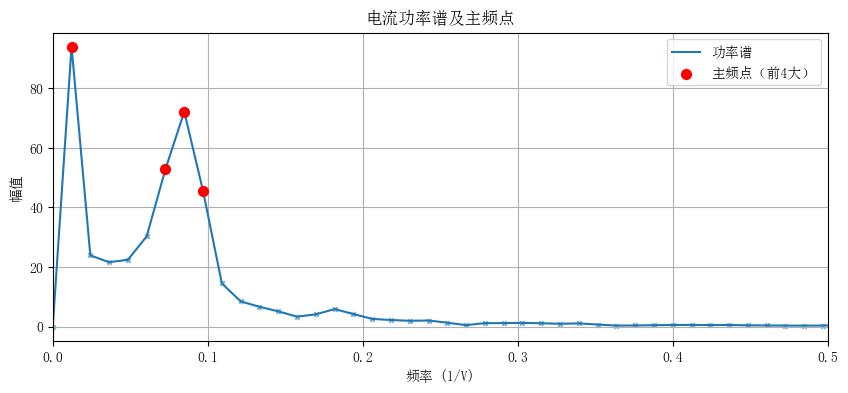

In [68]:
df=拒斥
# 假设 df 是您的 DataFrame
I = df['I'].values
I = detrend(I, type='linear')
dt = 0.5
N = len(I)
fft_vals = fft(I)                      # 未去趋势
freqs = fftfreq(N, d=dt)

# 只取正频率部分
amp = np.abs(fft_vals[:N//2])
freq_pos = freqs[:N//2]

# 排除直流分量（频率为0）和极低频（可选）
min_freq = -1
mask = freq_pos > min_freq
freq_masked = freq_pos[mask]
amp_masked = amp[mask]

# 按幅值降序排序，获取索引
sorted_idx = np.argsort(amp_masked)[::-1]   # 从大到小排序

# 确保有足够的频率点
if len(sorted_idx) >= 4:
    # 取第2、3、4大主频（索引1、2、3）
    second_freq = freq_masked[sorted_idx[1]]
    third_freq = freq_masked[sorted_idx[2]]
    fourth_freq = freq_masked[sorted_idx[3]]
    
    # 记录到数组中（假设已定义）
    第二主频[3] = second_freq
    第三主频[3] = third_freq
    第四主频[3] = fourth_freq
    
    # 打印结果
    print("按幅值排序的前几个频率:")
    for i in range(min(4, len(sorted_idx))):
        print(f"第{i+1}大: 频率 = {freq_masked[sorted_idx[i]]:.4f} /V, "
              f"周期 = {1/freq_masked[sorted_idx[i]]:.2f} V, "
              f"幅值 = {amp_masked[sorted_idx[i]]:.2f}")
else:
    print("频率点不足4个，无法获取第二、三、四主频。")

# 绘制功率谱并标记所有峰值（可选，保留原始绘图逻辑，但改为用排序后的前几个作为标记）
plt.figure(figsize=(10, 4))
plt.plot(freq_pos, amp, label='功率谱')
plt.scatter(freq_pos, amp, marker='x', s=10, alpha=0.6)
# 标记前四个最大幅值的点（可选）
if len(sorted_idx) >= 4:
    top_freqs = freq_masked[sorted_idx[:4]]
    top_amps = amp_masked[sorted_idx[:4]]
    plt.scatter(top_freqs, top_amps, color='red', s=50, zorder=5, label='主频点（前4大）')
plt.xlim(0, 0.5)
plt.xlabel('频率 (1/V)')
plt.ylabel('幅值')
plt.title('电流功率谱及主频点')
plt.legend()
plt.grid()
plt.show()

In [ ]:
1/第二主频,1/第三主频,1/第四主频

(array([11.78571429, 11.78571429, 11.78571429, 11.78571429]),
 array([10.3125, 10.3125, 10.3125, 13.75  ]),
 array([13.75  , 13.75  , 13.75  , 10.3125]))